# Assumptions

## What is an assumption anyways?

### Challenge: identifying assumptions

Take 5 minutes to list out as many assumptions as you can about the EIA 923 Puerto Rico data in the [data directory](../data/).

The goal is to get past the obvious ones and start thinking of some un-obvious assumptions - no need to limit yourself to 'realistic' ones at this stage.

## Testing Assumptions

In [1]:
import pandas as pd

In [2]:
monthly_gen_fuel = pd.read_parquet("../data/pr_gen_fuel_monthly.parquet")

### Example: testing assumptions

In [ ]:
renewables_2022 = monthly_gen_fuel[
    (monthly_gen_fuel["date"] >= "2022-01-01") &
    (monthly_gen_fuel["energy_source_code"].isin({"SUN", "WND", "WAT"}))
]
consumption_btu = renewables_2022["fuel_consumed_for_electricity_mmbtu"] * 1_000_000
net_gen_kwh = renewables_2022["net_generation_mwh"] * 1000
heat_rate = consumption_btu / net_gen_kwh

<Axes: >

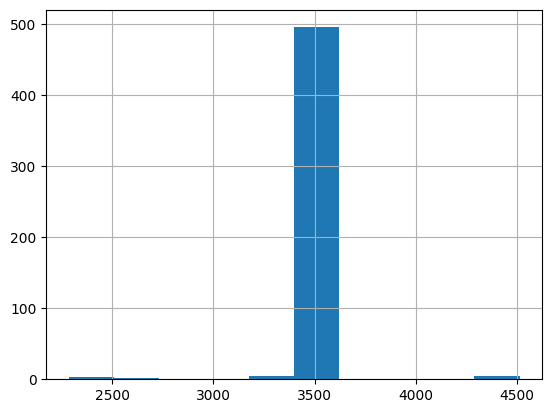

In [4]:
heat_rate.hist()

In [5]:
assert 1 == 1

In [6]:
assert 1 == 2

AssertionError: 

In [ ]:
assert heat_rate.std() / heat_rate.mean() <= 0.05

### Challenge: writing code to test an assumption

Pick an assumption from the list we generated above and write some code to assert that the assumption is true!

### Challenge: evaluating testability

The effort required to test these assumptions can be evaluated with the question,
"Can I imagine a snippet of code that would verify this assumption?"

Look at your list of assumptions.
Think about how you would write code to test each one.

Can you identify one that would be easy to test, and one that would be hard to test?

### Challenge: evaluating impact

Impact is hard to think about when you haven't built up a whole system yet.
 But you can usually sort problems into "won't cause any problems,"
"will cause problems which will be easy to notice (i.e. the whole program crashing),"
and "will cause problems which will be hard to notice (i.e., the data will just be wrong)."
In most cases,
it is better to have your program crash loudly than to have your program silently give you bad data.

Look at the list of your assumptions and imagine each one is not actually true.

Can you identify one example for each of the following?

* will probably break downstream work in some obvious way?
* will probably not break anything downstream?
* will cause some subtle and hard-to-notice problem?

### Challenge: evaluating likelihood

Evaluating likelihood can be difficult:
you are guessing at the future based on your experience of the past.
A heuristic is "can I imagine a situation where this assumption would be false?"
You'll build up a more nuanced intuition over time.

Look at the list of your assumptions and imagine a scenario in which they would not be true.

Can you identify an example scenario that:
* seem very plausible?
* seems very implausible?